In [8]:
import pandas as pd

# Load new full clinical file
clinical_new = pd.read_csv("CGGA_data/CGGA_clinical_full.txt", sep="\t")
print("New clinical shape:", clinical_new.shape)
print("Columns:", clinical_new.columns.tolist())

# Rename ID column if needed
clinical_new = clinical_new.rename(columns={"CGGA_ID": "ID"})

# Load original RNAseq (transposed)
rnaseq = pd.read_csv("CGGA_data/CGGA_mRNAseq.txt", sep="\t")
rnaseq_t = rnaseq.set_index("Gene_Name").T
rnaseq_t.index.name = "ID"
rnaseq_t = rnaseq_t.reset_index()

# Filter for GBM only
clinical_gbm = clinical_new[clinical_new["Histology"] == "GBM"]
print(f"\nGBM patients: {len(clinical_gbm)}")

# Check new columns
print("\nTMZ treated:", clinical_gbm["Chemo_status (TMZ treated=1;un-treated=0)"].value_counts())
print("\nRadio treated:", clinical_gbm["Radio_status (treated=1;un-treated=0)"].value_counts())
print("\nMGMT methylation:", clinical_gbm["MGMTp_methylation_status"].value_counts())

# Merge with RNAseq
combined = clinical_gbm.merge(rnaseq_t, on="ID", how="inner")
print(f"\nFinal combined shape: {combined.shape}")

# Save — this overwrites and updates everything downstream
combined.to_csv("CGGA_data/combined_clinical_RNAseq.csv", index=False)
print("Saved!")

New clinical shape: (693, 13)
Columns: ['CGGA_ID', 'PRS_type', 'Histology', 'Grade', 'Gender', 'Age', 'OS', 'Censor (alive=0; dead=1)', 'Radio_status (treated=1;un-treated=0)', 'Chemo_status (TMZ treated=1;un-treated=0)', 'IDH_mutation_status', '1p19q_codeletion_status', 'MGMTp_methylation_status']

GBM patients: 140

TMZ treated: Chemo_status (TMZ treated=1;un-treated=0)
1.0    109
0.0     20
Name: count, dtype: int64

Radio treated: Radio_status (treated=1;un-treated=0)
1.0    110
0.0     20
Name: count, dtype: int64

MGMT methylation: MGMTp_methylation_status
methylated       65
un-methylated    56
Name: count, dtype: int64

Final combined shape: (140, 24000)
Saved!


In [10]:
import pandas as pd

# Load new full clinical file
clinical_new = pd.read_csv("CGGA_data/CGGA_clinical_full.txt", sep="\t")

# Rename columns for cleanliness
clinical_new = clinical_new.rename(columns={
    "CGGA_ID": "ID",
    "Censor (alive=0; dead=1)": "Censor",
    "Radio_status (treated=1;un-treated=0)": "Radio_status",
    "Chemo_status (TMZ treated=1;un-treated=0)": "Chemo_status",
    "MGMTp_methylation_status": "MGMT_methylation"
})

# Filter for GBM
clinical_gbm = clinical_new[clinical_new["Histology"] == "GBM"]

# Load and transpose RNAseq
rnaseq = pd.read_csv("CGGA_data/CGGA_mRNAseq.txt", sep="\t")
rnaseq_t = rnaseq.set_index("Gene_Name").T
rnaseq_t.index.name = "ID"
rnaseq_t = rnaseq_t.reset_index()

# Merge and save
combined = clinical_gbm.merge(rnaseq_t, on="ID", how="inner")
combined.to_csv("CGGA_data/combined_clinical_RNAseq.csv", index=False)

print(f"Shape: {combined.shape}")
print("\nClinical columns:", combined.columns[:12].tolist())
print("\nCensor values:", combined["Censor"].value_counts())

Shape: (140, 24000)

Clinical columns: ['ID', 'PRS_type', 'Histology', 'Grade', 'Gender', 'Age', 'OS', 'Censor', 'Radio_status', 'Chemo_status', 'IDH_mutation_status', '1p19q_codeletion_status']

Censor values: Censor
1.0    110
0.0     23
Name: count, dtype: int64


In [11]:
import pandas as pd

clinical_new = pd.read_csv("CGGA_data/CGGA_clinical_full.txt", sep="\t")
clinical_new = clinical_new.rename(columns={"CGGA_ID": "ID"})

rnaseq = pd.read_csv("CGGA_data/CGGA_RNAseq.txt", sep="\t")
rnaseq_t = rnaseq.set_index("sample").T
rnaseq_t.index.name = "ID"
rnaseq_t = rnaseq_t.reset_index()

clinical_gbm = clinical_new[clinical_new["Histology"] == "GBM"]

print("Clinical GBM IDs (first 5):", clinical_gbm["ID"].head().tolist())
print("RNAseq IDs (first 5):", rnaseq_t["ID"].head().tolist())

print(f"\nClinical GBM patients: {len(clinical_gbm)}")
print(f"RNAseq samples: {len(rnaseq_t)}")

# Check overlap
overlap = set(clinical_gbm["ID"]) & set(rnaseq_t["ID"])
print(f"\nMatching IDs: {len(overlap)}")
print(f"Clinical IDs not in RNAseq: {len(set(clinical_gbm['ID']) - set(rnaseq_t['ID']))}")
print(f"RNAseq IDs not in Clinical: {len(set(rnaseq_t['ID']) - set(clinical_gbm['ID']))}")

# Show a sample of each to spot the format difference
print("\nSample clinical ID:", list(clinical_gbm["ID"])[0])
print("Sample RNAseq ID:", list(rnaseq_t["ID"])[0])

Clinical GBM IDs (first 5): ['CGGA_1017', 'CGGA_1036', 'CGGA_1041', 'CGGA_1075', 'CGGA_1086']
RNAseq IDs (first 5): ['TCGA-06-0178-01', 'TCGA-02-2483-01', 'TCGA-06-5417-01', 'TCGA-15-1444-01', 'TCGA-06-2570-01']

Clinical GBM patients: 140
RNAseq samples: 702

Matching IDs: 0
Clinical IDs not in RNAseq: 140
RNAseq IDs not in Clinical: 702

Sample clinical ID: CGGA_1017
Sample RNAseq ID: TCGA-06-0178-01


TypeError: NaNs were detected in the dataset. Try using pd.isnull to find the problematic values.

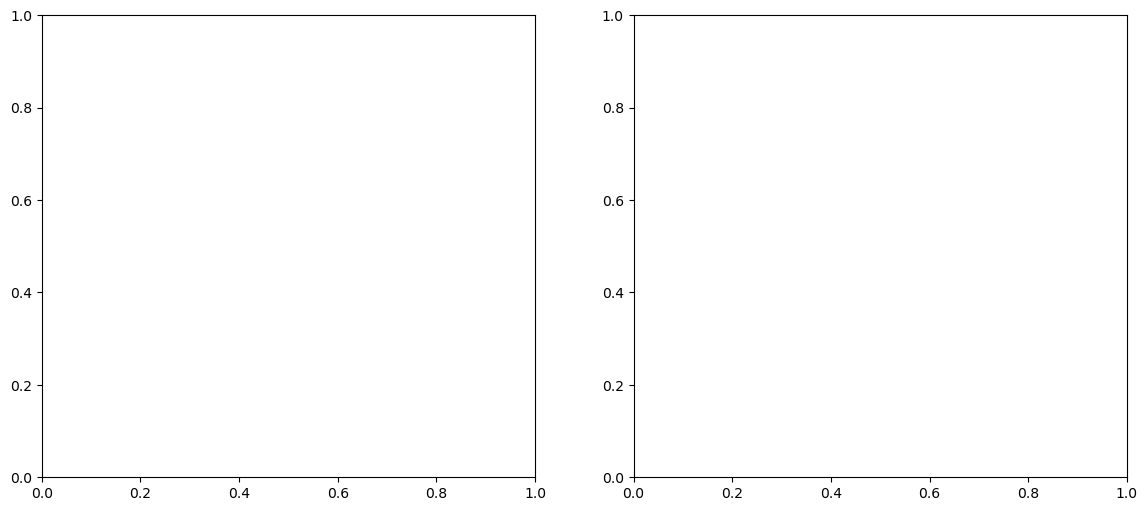

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Gender ---
ax1 = axes[0]
for gender in combined["Gender"].dropna().unique():
    mask = combined["Gender"] == gender
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Censor"], label=gender)
    kmf.plot_survival_function(ax=ax1)

ax1.set_title("Survival by Gender")
ax1.set_xlabel("Days")
ax1.set_ylabel("Survival Probability")

# --- Plot 2: Grade ---
ax2 = axes[1]
for grade in sorted(combined["Grade"].dropna().unique()):
    mask = combined["Grade"] == grade
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Censor"], label=grade)
    kmf.plot_survival_function(ax=ax2)

ax2.set_title("Survival by Grade")
ax2.set_xlabel("Days")
ax2.set_ylabel("Survival Probability")

plt.tight_layout()
plt.savefig("CGGA_data/survival_curves.png", dpi=150)
plt.show()
print("Saved!")

Age cutoff (median): 60.5


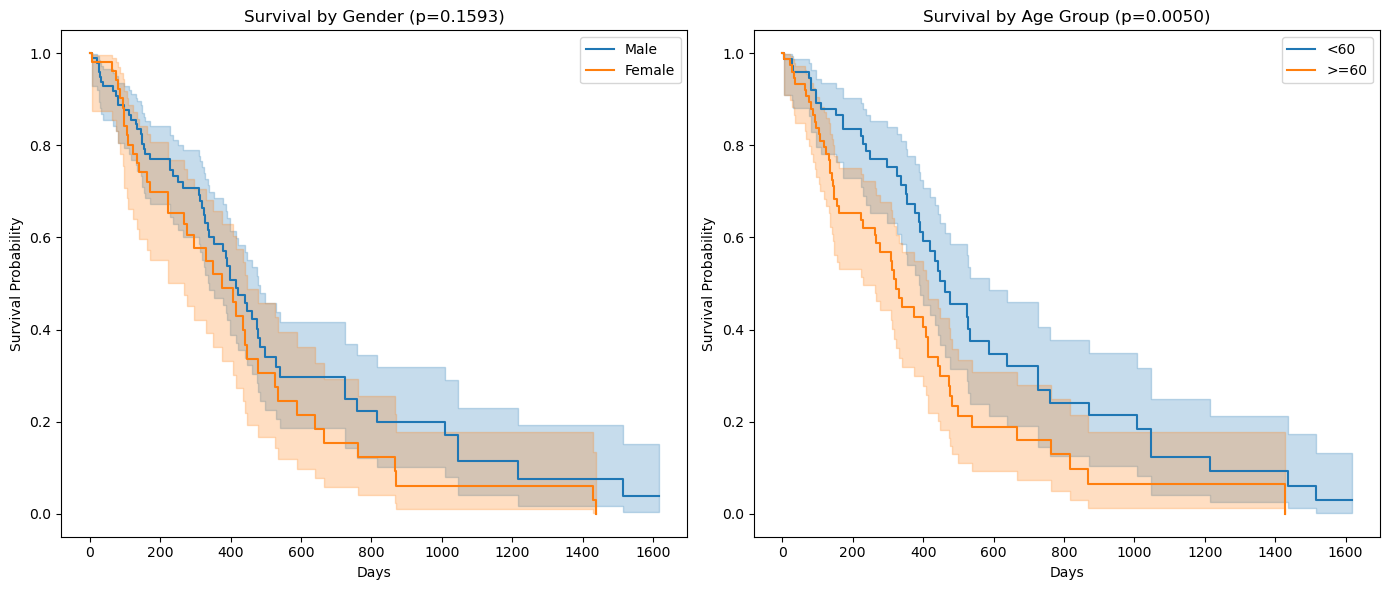

Done!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")

# Split age at median
age_cutoff = combined["Age"].median()
combined["Age_Group"] = combined["Age"].apply(lambda x: f"<{int(age_cutoff)}" if x < age_cutoff else f">={int(age_cutoff)}")
print(f"Age cutoff (median): {age_cutoff}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Gender ---
ax1 = axes[0]
groups = {}
for gender in combined["Gender"].dropna().unique():
    mask = combined["Gender"] == gender
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Censor"], label=gender)
    kmf.plot_survival_function(ax=ax1)
    groups[gender] = mask

# Log-rank p-value for gender
males = combined["Gender"] == "Male"
females = combined["Gender"] == "Female"
p_gender = logrank_test(
    combined.loc[males, "OS"], combined.loc[females, "OS"],
    combined.loc[males, "Censor"], combined.loc[females, "Censor"]
).p_value
ax1.set_title(f"Survival by Gender (p={p_gender:.4f})")
ax1.set_xlabel("Days")
ax1.set_ylabel("Survival Probability")

# --- Plot 2: Age Group ---
ax2 = axes[1]
for group in sorted(combined["Age_Group"].dropna().unique()):
    mask = combined["Age_Group"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Censor"], label=group)
    kmf.plot_survival_function(ax=ax2)

young = combined["Age_Group"] == combined["Age_Group"].unique()[0]
old = ~young
p_age = logrank_test(
    combined.loc[young, "OS"], combined.loc[old, "OS"],
    combined.loc[young, "Censor"], combined.loc[old, "Censor"]
).p_value
ax2.set_title(f"Survival by Age Group (p={p_age:.4f})")
ax2.set_xlabel("Days")
ax2.set_ylabel("Survival Probability")

plt.tight_layout()
plt.savefig("CGGA_data/survival_curves_v2.png", dpi=150)
plt.show()
print("Done!")

Age cutoff (median): 60.5


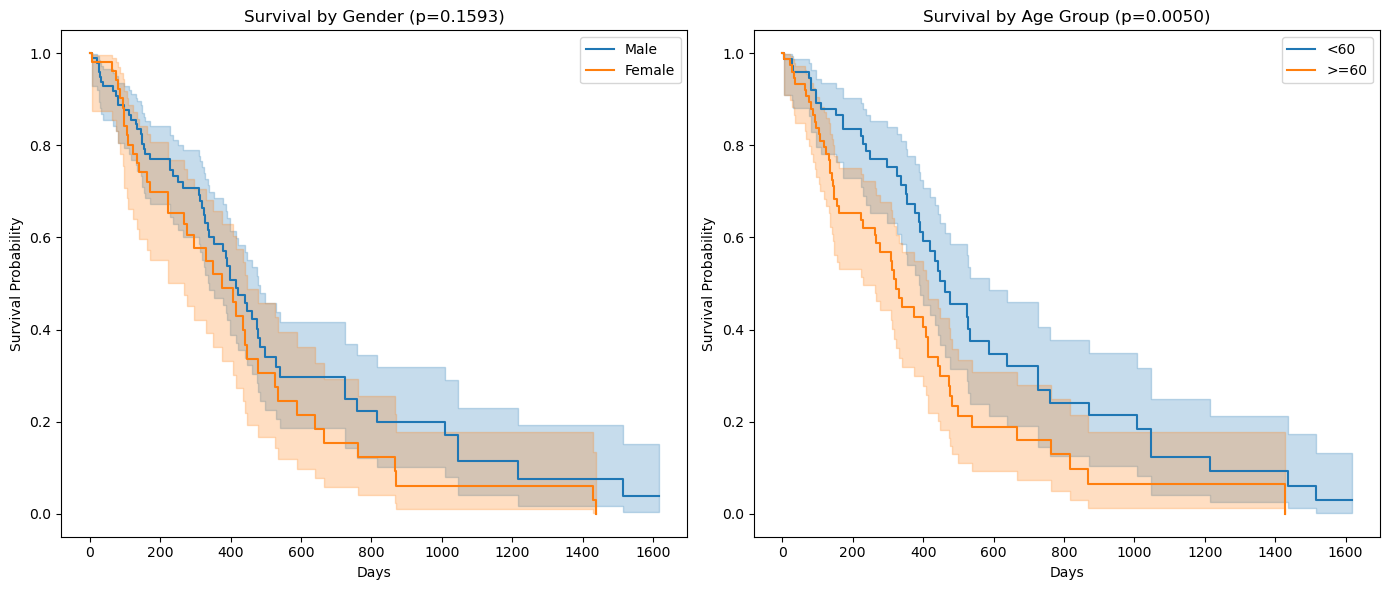

Done!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")

# Split age at median
age_cutoff = combined["Age"].median()
combined["Age_Group"] = combined["Age"].apply(lambda x: f"<{int(age_cutoff)}" if x < age_cutoff else f">={int(age_cutoff)}")
print(f"Age cutoff (median): {age_cutoff}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Gender ---
ax1 = axes[0]
groups = {}
for gender in combined["Gender"].dropna().unique():
    mask = combined["Gender"] == gender
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Censor"], label=gender)
    kmf.plot_survival_function(ax=ax1)
    groups[gender] = mask

# Log-rank p-value for gender
males = combined["Gender"] == "Male"
females = combined["Gender"] == "Female"
p_gender = logrank_test(
    combined.loc[males, "OS"], combined.loc[females, "OS"],
    combined.loc[males, "Censor"], combined.loc[females, "Censor"]
).p_value
ax1.set_title(f"Survival by Gender (p={p_gender:.4f})")
ax1.set_xlabel("Days")
ax1.set_ylabel("Survival Probability")

# --- Plot 2: Age Group ---
ax2 = axes[1]
for group in sorted(combined["Age_Group"].dropna().unique()):
    mask = combined["Age_Group"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Censor"], label=group)
    kmf.plot_survival_function(ax=ax2)

young = combined["Age_Group"] == combined["Age_Group"].unique()[0]
old = ~young
p_age = logrank_test(
    combined.loc[young, "OS"], combined.loc[old, "OS"],
    combined.loc[young, "Censor"], combined.loc[old, "Censor"]
).p_value
ax2.set_title(f"Survival by Age Group (p={p_age:.4f})")
ax2.set_xlabel("Days")
ax2.set_ylabel("Survival Probability")

plt.tight_layout()
plt.savefig("CGGA_data/survival_curves_v2.png", dpi=150)
plt.show()
print("Done!")

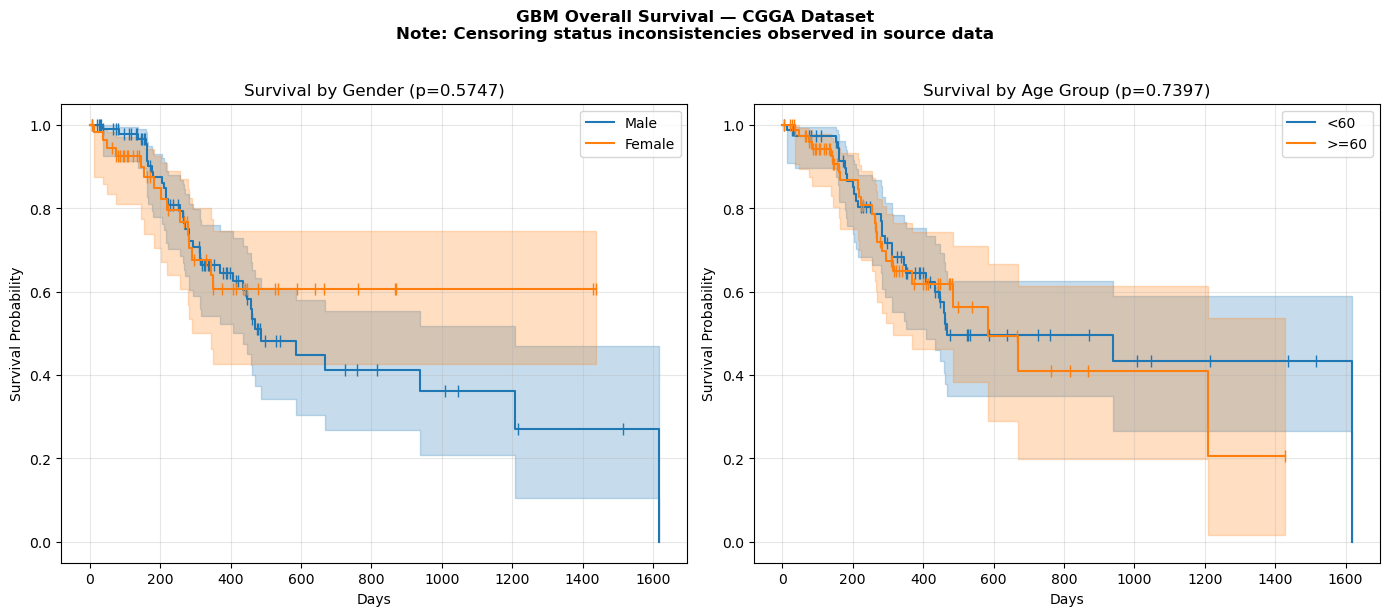

Gender p=0.5747, Age p=0.7397


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")

# Use original Censor, flipped for lifelines (0=death -> 1=event)
combined["Event"] = combined["Censor"].apply(lambda x: 1 if x == 0 else 0)

# Age groups at median
age_cutoff = combined["Age"].median()
combined["Age_Group"] = combined["Age"].apply(
    lambda x: f"<{int(age_cutoff)}" if x < age_cutoff else f">={int(age_cutoff)}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Gender ---
ax1 = axes[0]
for gender in combined["Gender"].dropna().unique():
    mask = combined["Gender"] == gender
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Event"], label=gender)
    kmf.plot_survival_function(ax=ax1, ci_show=True, show_censors=True,
                               censor_styles={"marker": "|", "ms": 8})

males = combined["Gender"] == "Male"
females = combined["Gender"] == "Female"
p_gender = logrank_test(
    combined.loc[males, "OS"], combined.loc[females, "OS"],
    combined.loc[males, "Event"], combined.loc[females, "Event"]
).p_value
ax1.set_title(f"Survival by Gender (p={p_gender:.4f})")
ax1.set_xlabel("Days")
ax1.set_ylabel("Survival Probability")
ax1.grid(True, alpha=0.3)

# --- Plot 2: Age Group ---
ax2 = axes[1]
for group in sorted(combined["Age_Group"].dropna().unique()):
    mask = combined["Age_Group"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Event"], label=group)
    kmf.plot_survival_function(ax=ax2, ci_show=True, show_censors=True,
                               censor_styles={"marker": "|", "ms": 8})

young = combined["Age_Group"] == f"<{int(age_cutoff)}"
old = combined["Age_Group"] == f">={int(age_cutoff)}"
p_age = logrank_test(
    combined.loc[young, "OS"], combined.loc[old, "OS"],
    combined.loc[young, "Event"], combined.loc[old, "Event"]
).p_value
ax2.set_title(f"Survival by Age Group (p={p_age:.4f})")
ax2.set_xlabel("Days")
ax2.set_ylabel("Survival Probability")
ax2.grid(True, alpha=0.3)

plt.suptitle("GBM Overall Survival — CGGA Dataset\n"
             "Note: Censoring status inconsistencies observed in source data",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("CGGA_data/survival_curves_final.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gender p={p_gender:.4f}, Age p={p_age:.4f}")

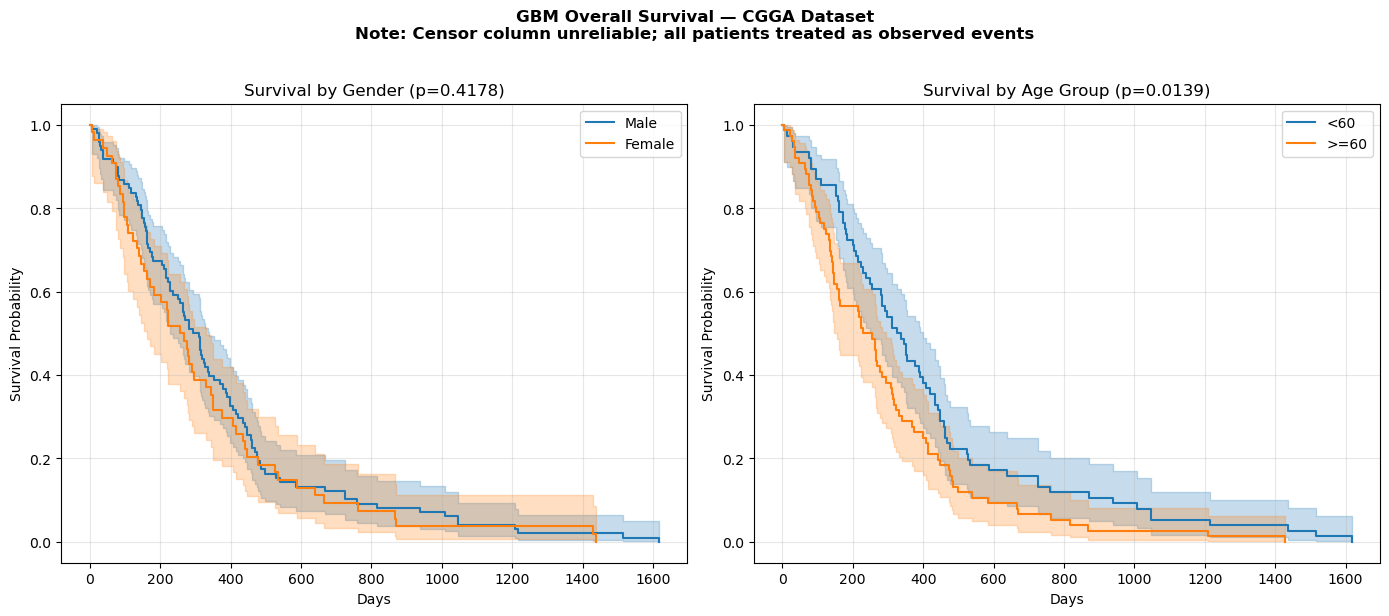

Gender p=0.4178, Age p=0.0139


In [15]:
# Treat all patients as events (no censoring)
combined["Event"] = 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Gender ---
ax1 = axes[0]
for gender in combined["Gender"].dropna().unique():
    mask = combined["Gender"] == gender
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Event"], label=gender)
    kmf.plot_survival_function(ax=ax1, ci_show=True)

males = combined["Gender"] == "Male"
females = combined["Gender"] == "Female"
p_gender = logrank_test(
    combined.loc[males, "OS"], combined.loc[females, "OS"],
    combined.loc[males, "Event"], combined.loc[females, "Event"]
).p_value
ax1.set_title(f"Survival by Gender (p={p_gender:.4f})")
ax1.set_xlabel("Days")
ax1.set_ylabel("Survival Probability")
ax1.grid(True, alpha=0.3)

# --- Plot 2: Age Group ---
ax2 = axes[1]
age_cutoff = combined["Age"].median()
combined["Age_Group"] = combined["Age"].apply(
    lambda x: f"<{int(age_cutoff)}" if x < age_cutoff else f">={int(age_cutoff)}"
)
for group in sorted(combined["Age_Group"].dropna().unique()):
    mask = combined["Age_Group"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Event"], label=group)
    kmf.plot_survival_function(ax=ax2, ci_show=True)

young = combined["Age_Group"] == f"<{int(age_cutoff)}"
old = combined["Age_Group"] == f">={int(age_cutoff)}"
p_age = logrank_test(
    combined.loc[young, "OS"], combined.loc[old, "OS"],
    combined.loc[young, "Event"], combined.loc[old, "Event"]
).p_value
ax2.set_title(f"Survival by Age Group (p={p_age:.4f})")
ax2.set_xlabel("Days")
ax2.set_ylabel("Survival Probability")
ax2.grid(True, alpha=0.3)

plt.suptitle("GBM Overall Survival — CGGA Dataset\n"
             "Note: Censor column unreliable; all patients treated as observed events",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("CGGA_data/survival_curves_final.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Gender p={p_gender:.4f}, Age p={p_age:.4f}")

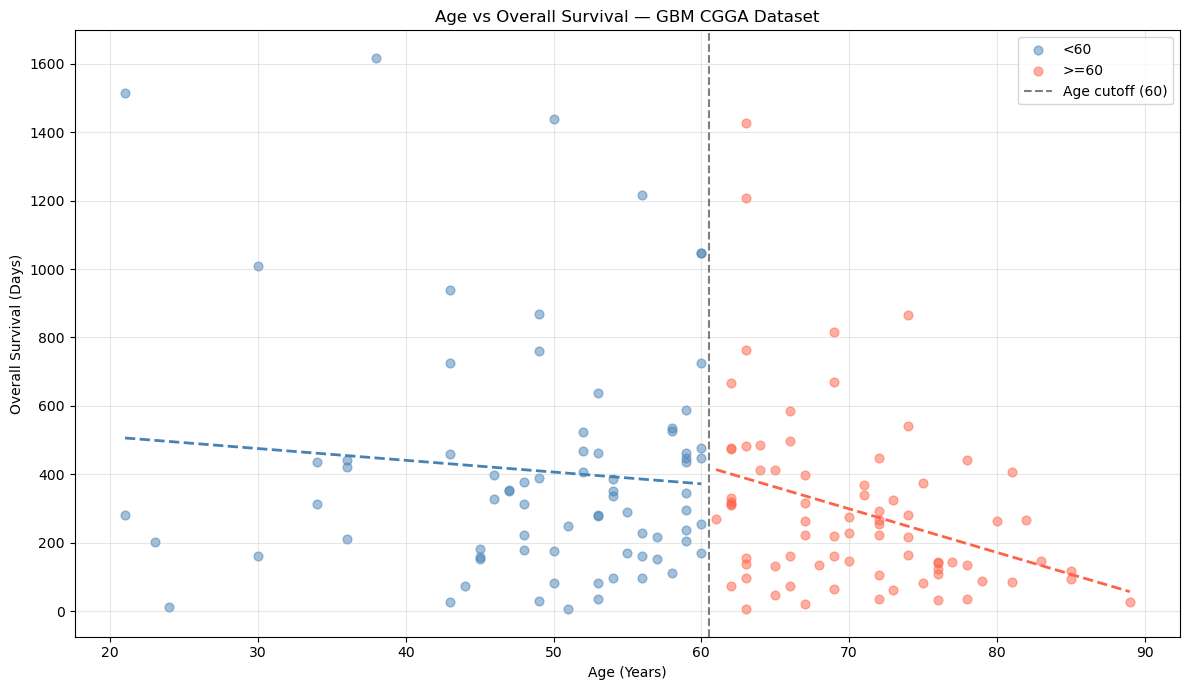

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")

fig, ax = plt.subplots(figsize=(12, 7))

# Color by age group
age_cutoff = combined["Age"].median()
combined["Age_Group"] = combined["Age"].apply(
    lambda x: f"<{int(age_cutoff)}" if x < age_cutoff else f">={int(age_cutoff)}"
)

colors = {"<60": "steelblue", ">=60": "tomato"}
for group, data in combined.groupby("Age_Group"):
    ax.scatter(data["Age"], data["OS"], 
               color=colors[group], alpha=0.5, s=40, label=group)

# Trend lines for each group
import numpy as np
for group, data in combined.groupby("Age_Group"):
    z = np.polyfit(data["Age"].dropna(), 
                   data.loc[data["Age"].notna(), "OS"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data["Age"].min(), data["Age"].max(), 100)
    ax.plot(x_line, p(x_line), color=colors[group], linewidth=2, linestyle="--")

ax.axvline(x=age_cutoff, color="black", linestyle="--", 
           alpha=0.5, label=f"Age cutoff ({int(age_cutoff)})")
ax.set_xlabel("Age (Years)")
ax.set_ylabel("Overall Survival (Days)")
ax.set_title("Age vs Overall Survival — GBM CGGA Dataset")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("CGGA_data/age_vs_os_scatter.png", dpi=150)
plt.show()

In [18]:
print("IDH mutation status values:")
print(combined["IDH_mutation_status"].value_counts())

IDH mutation status values:
IDH_mutation_status
Wildtype    139
Mutant        9
Name: count, dtype: int64


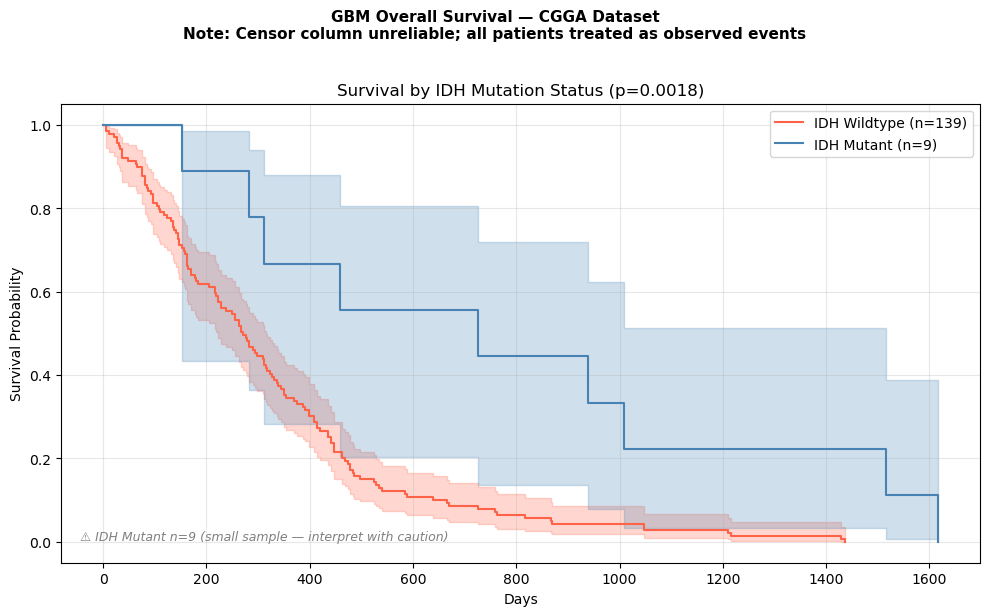

IDH p=0.0018


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")
combined["Event"] = 1

fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Wildtype": "tomato", "Mutant": "steelblue"}
for status in ["Wildtype", "Mutant"]:
    mask = combined["IDH_mutation_status"] == status
    kmf = KaplanMeierFitter()
    kmf.fit(combined.loc[mask, "OS"], combined.loc[mask, "Event"], label=f"IDH {status} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[status])

# Log-rank test
wt = combined["IDH_mutation_status"] == "Wildtype"
mut = combined["IDH_mutation_status"] == "Mutant"
p = logrank_test(
    combined.loc[wt, "OS"], combined.loc[mut, "OS"],
    combined.loc[wt, "Event"], combined.loc[mut, "Event"]
).p_value

ax.set_title(f"Survival by IDH Mutation Status (p={p:.4f})")
ax.set_xlabel("Days")
ax.set_ylabel("Survival Probability")
ax.grid(True, alpha=0.3)
ax.annotate(f"⚠️ IDH Mutant n=9 (small sample — interpret with caution)",
            xy=(0.02, 0.05), xycoords="axes fraction", fontsize=9,
            color="gray", style="italic")

plt.suptitle("GBM Overall Survival — CGGA Dataset\n"
             "Note: Censor column unreliable; all patients treated as observed events",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("CGGA_data/survival_idh.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"IDH p={p:.4f}")

In [1]:
import pandas as pd

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")

# Check all column names for anything treatment-related
treatment_cols = [c for c in combined.columns if any(
    keyword in c.upper() for keyword in 
    ["TMZ", "TEMOZOLOMIDE", "TREAT", "THERAPY", "CHEMO", "RADIO", "MGMT", "KARNOFSKY", "KPS", "RESECT"]
)]
print("Treatment-related columns found:", treatment_cols)

# Also check clinical file directly
clinical = pd.read_csv("CGGA_data/CGGA_clinical.txt", sep="\t")
print("\nAll clinical columns:", clinical.columns.tolist())

Treatment-related columns found: ['MGMT']

All clinical columns: ['ID', 'Histology', 'Grade', 'Gender', 'Age', 'OS', 'Censor', 'IDH_mutation_status', '1p19q_codeletion_status']
